In [ ]:
"""Regime-by-algorithm Sharpe matrix: which strategy wins in which HMM regime.

Fits the K=3 HMM on 1988-1997, names states by fitted mean return (bull /
sideways / bear), runs 8 causal strategies on 1998-2001, and reports each
strategy's Sharpe within each regime.
"""

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from sklearn.ensemble import RandomForestClassifier

project_root = Path(__file__).resolve().parents[2]
sys.path.insert(0, str(project_root / "src"))

from model_evaluation.market_strategy import (  # noqa: E402  (needs path setup)
    apply_weights,
    buy_and_hold,
    moving_average_timing,
    volatility_target,
)

DATA_PATH = project_root / "data/processed/sp500_index_price.csv"
MAX_ITER, TOL = 120, 1e-3
MIN_COVAR = 1e-5
"""Floor on per-state variances; mirrors the local package's ``MIN_VARIANCE``."""

N_STATES = 3
N_RESTARTS = 10
"""Baum-Welch is non-convex; keep the best-likelihood of 10 seeds."""

VOLATILITY_DAYS, MOMENTUM_DAYS = 60, 20
COST_BPS = 5.0
"""Transaction cost in basis points per unit of strategy turnover."""

logging.getLogger("hmmlearn").setLevel(logging.ERROR)

In [ ]:
data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"]).sort_values("YYYYMMDD")
prices = data.set_index("YYYYMMDD")["DlyPrcInd"]
returns = np.log(prices).diff().dropna().rename("r_t")
transformed = pd.concat(
    [
        returns.rename("r_t"),
        returns.rolling(VOLATILITY_DAYS, min_periods=VOLATILITY_DAYS)
        .std(ddof=1)
        .rename("sigma_t"),
        returns.rolling(MOMENTUM_DAYS, min_periods=MOMENTUM_DAYS)
        .mean()
        .rename("m_t"),
    ],
    axis=1,
).dropna()

training = returns.loc["1988":"1997"]
evaluation = returns.loc["1998":"2001"]
X_train = transformed.loc[training.index].to_numpy()

In [ ]:
data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"]).sort_values("YYYYMMDD")
prices = data.set_index("YYYYMMDD")["DlyPrcInd"]
returns = np.log(prices).diff().dropna().rename("r_t")
transformed = pd.concat(
    [
        returns.rename("r_t"),
        returns.rolling(VOLATILITY_DAYS, min_periods=VOLATILITY_DAYS)
        .std(ddof=1)
        .rename("sigma_t"),
        returns.rolling(MOMENTUM_DAYS, min_periods=MOMENTUM_DAYS)
        .mean()
        .rename("m_t"),
    ],
    axis=1,
).dropna()

training = returns.loc["1988":"1997"]
evaluation = returns.loc["1998":"2001"]
X_train = transformed.loc[training.index].to_numpy()

## Fit the K=3 HMM and name the regimes by fitted moments


def fit_hmmlearn(X, n_states):
    """Fit a Gaussian HMM over N_RESTARTS seeds, keeping the best likelihood.

    Args:
        X: Feature matrix, one row per day: ``[r_t, sigma_t, m_t]``.
        n_states: Number of hidden states.

    Returns:
        The fitted model with the highest total log-likelihood.
    """
    best, best_score = None, -np.inf
    for seed in range(N_RESTARTS):
        model = GaussianHMM(
            n_components=n_states, covariance_type="full", min_covar=MIN_COVAR,
            n_iter=MAX_ITER, tol=TOL, random_state=seed,
        )
        try:
            model.fit(X)
            score = model.score(X)
        except ValueError:  # NaN params from a collapsed state
            continue
        if np.isfinite(score) and score > best_score:
            best, best_score = model, score
    if best is None:
        raise RuntimeError(f"All {N_RESTARTS} restarts collapsed")
    return best


model = fit_hmmlearn(X_train, N_STATES)
fitted = pd.DataFrame(
    {
        "mean_r_%day": 100 * model.means_[:, 0],
        "sd_r_%day": 100 * np.sqrt(model.covars_[:, 0, 0]),
        "mean_sigma_%day": 100 * model.means_[:, 1],
    }
)

# Naming by economics, not by a single axis: the crisis state is the
# highest-volatility one; bull earns the most; what is left chops sideways.
bull = int(fitted["mean_r_%day"].idxmax())
bear = int(fitted["sd_r_%day"].idxmax())
sideways = int(({0, 1, 2} - {bull, bear}).pop())
regime_name = {bear: "bear", sideways: "sideways", bull: "bull"}
print(fitted.round(3))
print("transitions:\n", np.round(model.transmat_, 3))
print("labels:", regime_name)

   mean_r_%day  sd_r_%day  mean_sigma_%day
0       -0.009      1.085            1.036
1        0.076      0.697            0.671
2       -0.003      2.050            1.743
transitions:
 [[0.964 0.026 0.011]
 [0.007 0.992 0.001]
 [0.062 0.    0.938]]
labels: {2: 'bear', 0: 'sideways', 1: 'bull'}


In [ ]:
## Label every evaluation day (Viterbi over the full 1988-2001 history)

X_full = transformed.to_numpy()
_, path = model.decode(X_full)
labels_full = pd.Series([regime_name[s] for s in path], index=transformed.index)
labels = labels_full.loc[evaluation.index]
print(labels.value_counts().to_string())
print(f"\nswitches in eval window: {(labels != labels.shift()).sum() - 1}")

## Rule-based strategies (no fitting; standard knobs, causal)

p_eval = prices.loc[evaluation.index]

sideways    579
bear        284
bull        141

switches in eval window: 27


rf train acc (in-sample): 1.0
regime day counts (1998-2001):
 n_days_bear    284.000000
n_days_side    579.000000
n_days_bull    141.000000
bear             0.131224
sideways        -0.134779
bull             2.844418
all              0.204225

sharpe by regime:
                bear  sideways  bull   all
buy_and_hold   0.13     -0.13  2.84  0.20
ma_50_200      0.38      0.20  0.92  0.28
vol_target_60 -0.23     -0.52  1.37 -0.22
tsmom_126      0.29     -0.07  0.94  0.12
mean_rev_z20  -0.02      0.40  1.26  0.22
logistic_up    0.72     -0.53 -2.06 -0.13
ridge_return   1.01     -0.44 -1.32  0.12
random_forest  0.53     -0.62 -2.15 -0.30


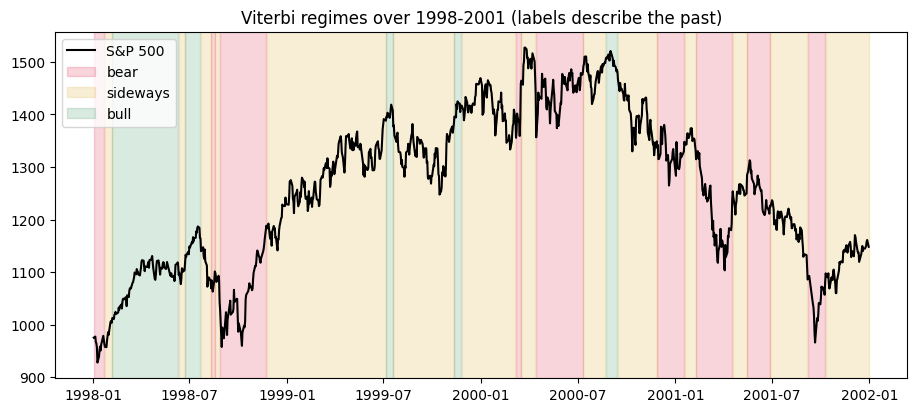

In [ ]:
def sign_momentum(prices_, lookback=126):
    """Long while the trailing ``lookback``-day return is positive (TSMOM)."""
    return np.sign(prices_ / prices_.shift(lookback) - 1.0).shift(1).fillna(0.0)


def mean_reversion(prices_, lookback=20, z_entry=-1.0):
    """Long after a dip: price below its ``lookback``-mean by |z_entry| sd."""
    z = ((prices_ - prices_.rolling(lookback).mean())
         / prices_.rolling(lookback).std(ddof=1))
    return (z < z_entry).astype(float).shift(1).fillna(0.0)


weights = {
    "buy_and_hold": buy_and_hold(evaluation),
    "ma_50_200": moving_average_timing(p_eval, fast=50, slow=200),
    "vol_target_60": volatility_target(evaluation, days=60, target_volatility=0.15),
    "tsmom_126": sign_momentum(p_eval, lookback=126),
    "mean_rev_z20": mean_reversion(p_eval, lookback=20, z_entry=-1.0),
}

## ML strategies: fitted on 1988-1997 ONLY, lagged features predicting r_t
# ML features are shifted emissions (t-1) - the HMM eats current-day emissions;
# supervised features must not contain the day the label measures.

feature_cols = ["r_t", "sigma_t", "m_t"]
X_train_ml = transformed.loc[training.index, feature_cols].to_numpy()
y_train = (training.to_numpy() > 0).astype(int)          # sign of r_t
mu, sd = X_train_ml.mean(0), X_train_ml.std(0) + 1e-12

X_eval_ml = transformed.loc[evaluation.index, feature_cols].to_numpy()
Xtr_s = (X_train_ml - mu) / sd
Xev_s = (X_eval_ml - mu) / sd


def logistic_weights(Xtr, ytr, Xev, lr=0.05, iters=3000, ridge=1.0):
    """Fit P(up) by ridge-penalized logistic regression; return 2p - 1."""
    Xtr1 = np.column_stack([np.ones(len(Xtr)), Xtr])
    Xev1 = np.column_stack([np.ones(len(Xev)), Xev])
    w = np.zeros(Xtr1.shape[1])
    for _ in range(iters):
        p = 1.0 / (1.0 + np.exp(-Xtr1 @ w))
        grad = Xtr1.T @ (p - ytr) / len(ytr) + ridge * w / len(ytr)
        w -= lr * grad
    p_ev = 1.0 / (1.0 + np.exp(-Xev1 @ w))
    return np.clip(2.0 * p_ev - 1.0, -1.0, 1.5)


weights["logistic_up"] = pd.Series(
    logistic_weights(Xtr_s, y_train, Xev_s), index=evaluation.index
)

# ridge on the raw next-day return, position scaled by the train sd
A = np.column_stack([np.ones(len(Xtr_s)), Xtr_s])
lam = 10.0
beta = np.linalg.solve(A.T @ A + lam * np.eye(A.shape[1]), A.T @ training.to_numpy())
yhat = np.column_stack([np.ones(len(Xev_s)), Xev_s]) @ beta
weights["ridge_return"] = pd.Series(
    np.clip(yhat / training.std(ddof=1), -1.0, 1.5), index=evaluation.index
)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=3, min_samples_leaf=50, random_state=0, n_jobs=-1
).fit(Xtr_s, y_train)
p_rf = rf.predict_proba(Xev_s)[:, 1]
print("rf train acc (in-sample):", round(rf.score(Xtr_s, y_train), 3))
weights["random_forest"] = pd.Series(
    np.clip(2.0 * p_rf - 1.0, -1.0, 1.5), index=evaluation.index
)

# lagged features -> weights for day t are decided with data through t-1
for name in ["logistic_up", "ridge_return", "random_forest"]:
    weights[name] = weights[name].shift(1).fillna(0.0)

## Per-regime Sharpe table (annualized, 5 bps costs, 1998-2001)


def sharpe(pnl):
    """Annualized Sharpe; ``nan`` for samples under 20 days."""
    return np.nan if len(pnl) < 20 else pnl.mean() / pnl.std(ddof=1) * np.sqrt(252)


pnl = {name: apply_weights(evaluation, w, cost_bps=COST_BPS)
       for name, w in weights.items()}
rows = []
for name, p in pnl.items():
    row = {
        "n_days_bear": int((labels == "bear").sum()),
        "n_days_side": int((labels == "sideways").sum()),
        "n_days_bull": int((labels == "bull").sum()),
    }
    for reg in ["bear", "sideways", "bull"]:
        row[reg] = sharpe(p[labels == reg])
    row["all"] = sharpe(p)
    rows.append(row)
table = pd.DataFrame(rows, index=list(pnl)).drop(
    columns=[c for c in rows[0] if c.startswith("n_days")]
)
counts = pd.Series(rows[0]).rename("n_days")
print("regime day counts (1998-2001):\n", counts.to_string())
print("\nsharpe by regime:\n", table.round(2).to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(p_eval, color="black", label="S&P 500")
colors = {"bear": "crimson", "sideways": "goldenrod", "bull": "seagreen"}
top = p_eval.max()
for reg, c in colors.items():
    ax.fill_between(labels.index, 0, top, where=(labels == reg).values,
                    transform=ax.get_xaxis_transform(), color=c, alpha=0.18, label=reg)
ax.legend(loc="upper left")
ax.set(title="Viterbi regimes over 1998-2001 (labels describe the past)")
plt.show()

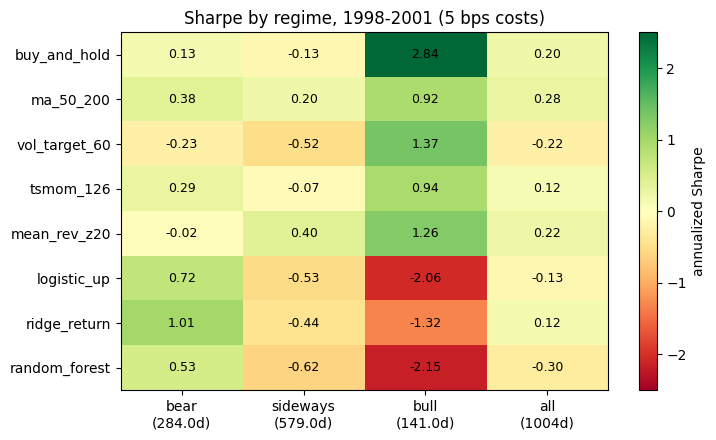

In [ ]:
cols = ["bear", "sideways", "bull", "all"]
day_labels = {
    "bear": counts["n_days_bear"], "sideways": counts["n_days_side"],
    "bull": counts["n_days_bull"], "all": int(len(evaluation)),
}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(table[cols].to_numpy(dtype=float), cmap="RdYlGn",
               vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_xticks(range(len(cols)), [f"{c}\n({day_labels[c]}d)" for c in cols])
ax.set_yticks(range(len(table)), list(table.index))
for i in range(table.shape[0]):
    for j, c in enumerate(cols):
        ax.text(j, i, f"{table.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set(title="Sharpe by regime, 1998-2001 (5 bps costs)")
fig.colorbar(im, label="annualized Sharpe")
fig.tight_layout()